In [19]:
import serial
import time
import csv
import pandas as pd
import matplotlib.pyplot as plt

In [25]:
PORT = 'COM4'         
BAUD_RATE = 9600

def capturar_e_salvar_csv(duracao_segundos, nome_arquivo):
    print(f"=== INICIANDO CAPTURA PARA: {nome_arquivo} ===")
    print("Prepare-se... O LED vai piscar!")
    
    try:
        ser = serial.Serial(PORT, BAUD_RATE, timeout=0.1)
        time.sleep(2) # Tempo de reset do Arduino
        ser.reset_input_buffer()
        
        # Abre o arquivo CSV para escrita
        with open(nome_arquivo, mode='w', newline='') as file:
            writer = csv.writer(file)
            writer.writerow(['Tempo (s)', 'Amplitude (V)']) # Cabeçalho
            
            # Envia comando de START (Liga LED)
            ser.write(b'1')
            tempo_inicial = time.time()
            
            while (time.time() - tempo_inicial) < duracao_segundos:
                if ser.in_waiting > 0:
                    linha = ser.readline().decode('utf-8').strip()
                    if linha:
                        try:
                            tensao = float(linha)
                            tempo_relativo = time.time() - tempo_inicial
                            writer.writerow([round(tempo_relativo, 3), tensao])
                        except ValueError:
                            pass
                            
            # Envia comando de STOP (Desliga LED)
            ser.write(b'0')
            
        print(f"Captura finalizada! Dados salvos em '{nome_arquivo}'.\n")
        
    except Exception as e:
        print(f"Erro: {e}")
    finally:
        if 'ser' in locals() and ser.is_open:
            ser.close()

In [26]:
capturar_e_salvar_csv(15, 'descansado.csv')

=== INICIANDO CAPTURA PARA: descansado.csv ===
Prepare-se... O LED vai piscar!
Captura finalizada! Dados salvos em 'descansado.csv'.



In [27]:
capturar_e_salvar_csv(15, 'fadigado.csv')

=== INICIANDO CAPTURA PARA: fadigado.csv ===
Prepare-se... O LED vai piscar!
Captura finalizada! Dados salvos em 'fadigado.csv'.



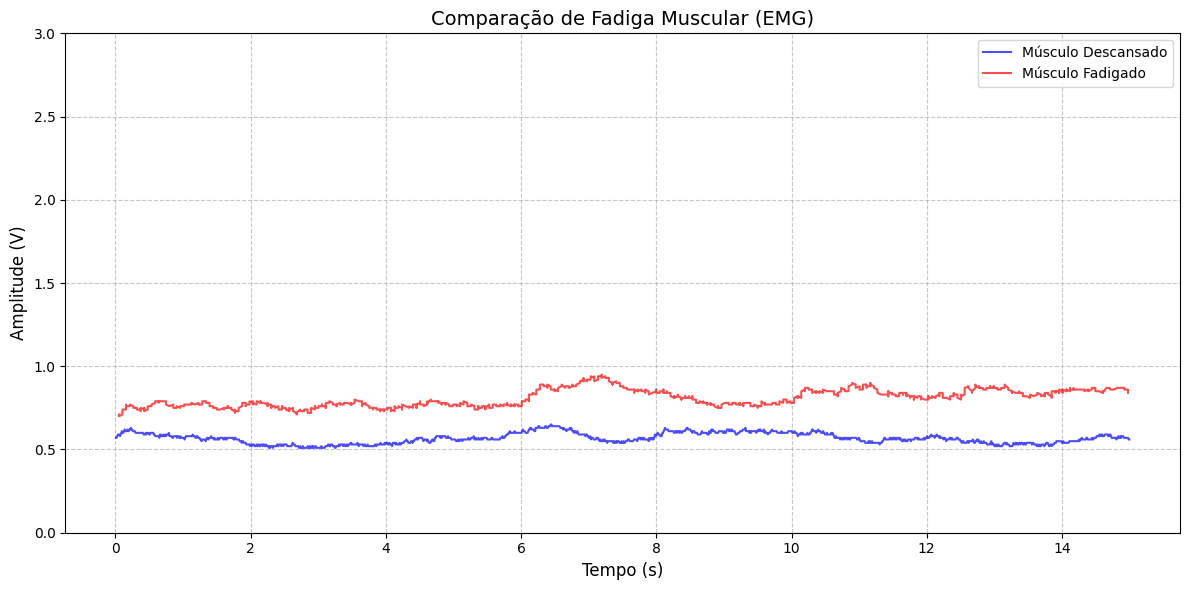

In [29]:
df_descansado = pd.read_csv('descansado.csv')
df_fadigado = pd.read_csv('fadigado.csv')

# Configuração da Figura
plt.figure(figsize=(12, 6))

# Plota a curva azul (Pré-fadiga)
plt.plot(df_descansado['Tempo (s)'], df_descansado['Amplitude (V)'], 
         color='blue', alpha=0.7, label='Músculo Descansado')

# Plota a curva vermelha (Pós-fadiga)
plt.plot(df_fadigado['Tempo (s)'], df_fadigado['Amplitude (V)'], 
         color='red', alpha=0.7, label='Músculo Fadigado')

# Estilização baseada na sua imagem
plt.title("Comparação de Fadiga Muscular (EMG)", fontsize=14)
plt.xlabel("Tempo (s)", fontsize=12)
plt.ylabel("Amplitude (V)", fontsize=12)

# ================= AJUSTE DO EIXO Y =================
plt.ylim(0, 3)
plt.yticks([0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]) 
# =========================================================

plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)

# Mostra e salva o gráfico final
plt.tight_layout()
plt.show()